In [33]:
from utils.paths import DESCRIPTORS_DIR,DATABASE_DIR,SAMPLING_DIR,PLOTS_DIR,PREDICTIONS_DIR,RAW_DIR

In [34]:
import ternary
import matplotlib.pyplot as plt
import mpltern
import matplotlib as mpl
import seaborn as sns

In [35]:
from preprocessing.database_manager import DatabaseManager
from preprocessing.DataPreprocessor import DataPreprocessor
from preprocessing.DescriptorEngineer import AlloyDescriptorCalculator,ElementPropertyLoader
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

import numpy as np
import pandas as pd
import pickle

Data extraction

In [36]:
#========= Experimental compositions ================
db = DatabaseManager(DATABASE_DIR/"Ternary_round1.db")

df_optical = db.table_dataframe('Optical_properties')
df_comp = db.table_dataframe('compositions')
db.close()

df_merged = df_optical.merge(df_comp, on="ID", how="inner")
tern_1550 = df_merged[np.isclose(df_merged["wavelength_nm"].astype(float), 1552.0)]

# ============== Descriptors ======================================= #
atomic_radius = pd.read_pickle(DESCRIPTORS_DIR/"Atomic_radius.pkl")
electronegativity = pd.read_pickle(DESCRIPTORS_DIR/"electronegativity.pkl")
valence_electrons = pd.read_pickle(DESCRIPTORS_DIR/"Valence_electrons.pkl")

atomic_radius = atomic_radius.set_index("symbol")
electronegativity = electronegativity.set_index("Symbol")
valence_electrons = valence_electrons.set_index("symbol")

atomic_radius = atomic_radius.rename(columns={"Metallic": "atomic_radius"})
valence_electrons = valence_electrons.rename(columns={"valence": "valence_electrons"})

elem_props = (
    atomic_radius
    .join(electronegativity)
    .join(valence_electrons)
)

calc = AlloyDescriptorCalculator(elem_props=elem_props)
df_ternary_1f_properties = calc.add_all_descriptors(tern_1550[['Cu','Ni','Al']])

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [37]:
comp_columns = ["Cu", "Ni", "Al"]

df_ternary_1f_properties = df_ternary_1f_properties.merge(
    tern_1550[comp_columns + ["e1", "e2"]],
    on=comp_columns,
    how="left"
)

All space prediction

In [38]:
#========= Predicted Compositions ================
db = DatabaseManager(DATABASE_DIR/"Calculate_EMA.db")

df_optical_all = db.table_dataframe('Optical_properties')
df_comp_all = db.table_dataframe('compositions')
db.close()

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Calculate_EMA.db
Database connection closed


In [39]:
df_space = calc.add_all_descriptors(df_comp_all[['Cu','Ni','Al']])
df_space.to_csv(RAW_DIR/"CuNiAl_descriptors.csv", index=False)

Random Sampling

In [51]:
DP = DataPreprocessor()
X = df_ternary_1f_properties.drop(columns=["e1", "e2"])
y = df_ternary_1f_properties['e2']

X_train_split, X_test_split, y_train,y_test = DP.split_training(X,y)
train_comp = np.asarray(X_train_split[['Cu','Ni','Al']], dtype=float)*100
test_comp = np.asarray(X_test_split[['Cu','Ni','Al']], dtype=float)*100

random_split = {}
random_split['X_train_split'] = X_train_split
random_split['X_test_split'] = X_test_split
random_split['y_train'] = y_train
random_split['y_test'] = y_test

with open(SAMPLING_DIR/"random_split", "wb") as f:
    pickle.dump(random_split, f)

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


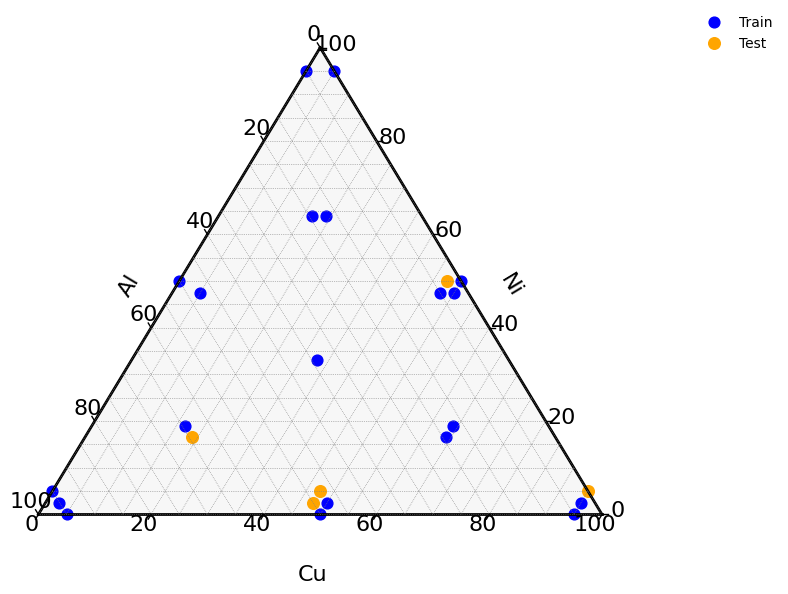

In [41]:
scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp, scale)
pts_B = to_ternary_points(test_comp, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
#plt.show()
plt.savefig(PLOTS_DIR/"Random_Sampling.svg", format="svg", bbox_inches="tight")

Sampling using clustering

In [70]:
X_numpy = np.asarray(X, dtype=float)
y_numpy = np.asarray(y, dtype=float)

X_n2 = X_numpy[:,3:]

k = 4 # clusters number
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_n2)

train_idx = []
test_idx = []

for c in np. unique(clusters):
    clusters_indices = np.where(clusters == c)[0]
    
    tr, te = train_test_split(
        clusters_indices,
        test_size=0.15,
        random_state=42
        )
    train_idx.extend(tr)
    test_idx.extend(te)
    
train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train_cluster = X.iloc[train_idx].copy()
X_test_cluster = X.iloc[test_idx].copy()

y_train_cluster = y.iloc[train_idx].copy()
y_test_cluster = y.iloc[test_idx].copy()

cluster_split = {}
cluster_split['X_train_split'] = X_train_cluster
cluster_split['X_test_split'] = X_test_cluster
cluster_split['y_train'] = y_train_cluster
cluster_split['y_test'] = y_test_cluster

with open(SAMPLING_DIR/"cluster_split", "wb") as f:
    pickle.dump(cluster_split, f)

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


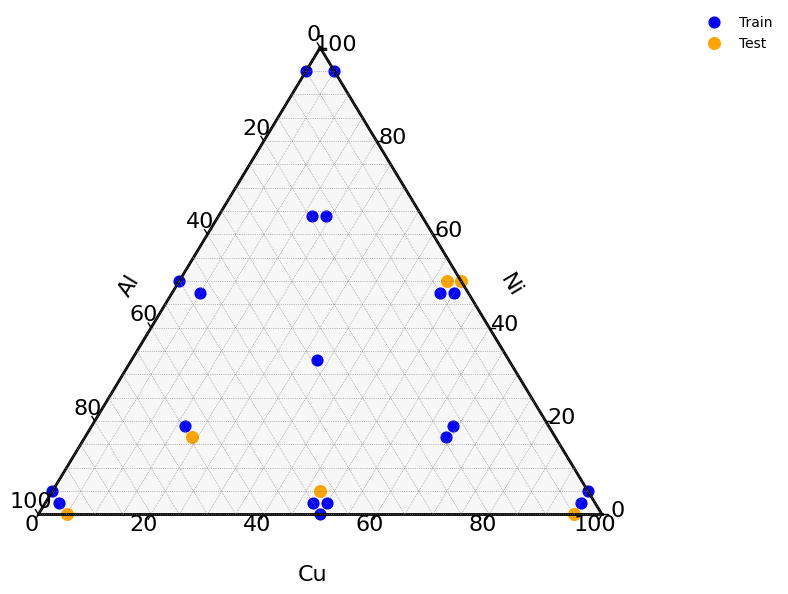

In [43]:
train_comp_cluster = np.asarray(cluster_split['X_train_split'][['Cu','Ni','Al']], dtype=float)*100
test_comp_cluster = np.asarray(cluster_split['X_test_split'][['Cu','Ni','Al']], dtype=float)*100

scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp_cluster, scale)
pts_B = to_ternary_points(test_comp_cluster, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
plt.savefig(PLOTS_DIR/"Cluster_kmeans_Sampling.svg", format="svg", bbox_inches="tight")

Previous splitting

In [68]:
train_comp = pd.read_csv(PREDICTIONS_DIR/"ANN_Predictions/train_exp_comp")
test_comp = pd.read_csv(PREDICTIONS_DIR/"ANN_Predictions/test_exp_comp")


In [69]:
comp_columns = ["Cu", "Ni", "Al"]
features_columns = ['r','del_r','del_EN','S','VEC']
property = ['e2']


train_comp_2 = train_comp.merge(
    df_ternary_1f_properties[comp_columns + features_columns],
    on=comp_columns,
    how="left"
)

train_e2 = train_comp.merge(
    df_ternary_1f_properties[comp_columns+property],
    on=comp_columns,
    how="left"
)

test_comp_2 = test_comp.merge(
    df_ternary_1f_properties[comp_columns + features_columns],
    on=comp_columns,
    how="left"
)

test_e2 = test_comp.merge(
    df_ternary_1f_properties[comp_columns+property],
    on=comp_columns,
    how="left"
)


cluster_split = {}
cluster_split['X_train_split'] = train_comp_2[comp_columns+features_columns]
cluster_split['X_test_split'] = test_comp_2[comp_columns+features_columns]
cluster_split['y_train'] = train_e2['e2']
cluster_split['y_test'] = test_e2['e2']

with open(SAMPLING_DIR/"cluster_split", "wb") as f:
    pickle.dump(cluster_split, f)

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


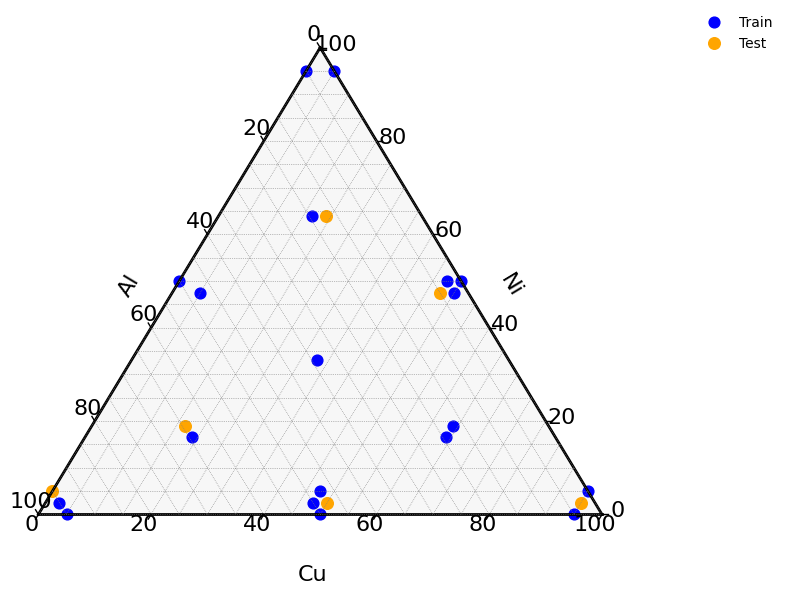

In [50]:
train_comp_cluster = np.asarray(cluster_split['X_train_split'][['Cu','Ni','Al']], dtype=float)*100
test_comp_cluster = np.asarray(cluster_split['X_test_split'][['Cu','Ni','Al']], dtype=float)*100

scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp_cluster, scale)
pts_B = to_ternary_points(test_comp_cluster, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
plt.savefig(PLOTS_DIR/"Cluster_kmeans_Sampling.svg", format="svg", bbox_inches="tight")